In [52]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import convolve2d
from skimage.util import random_noise

In [53]:
def correlation_method(image, mask):
    size_mask = mask.shape
    size_image = image.shape

    norm_mask = mask / np.sum(mask ** 2)


    expanded_image = np.insert(image, 0, np.tile(0, (size_mask[0] // 2, 1)), axis=0)
    expanded_image = np.insert(expanded_image, size_image[0]+1, np.tile(0, (size_mask[0] // 2, 1)), axis=0)

    expanded_image = np.insert(expanded_image, 0, np.tile(0, (size_mask[1] // 2, 1)), axis=1)
    expanded_image = np.insert(expanded_image, size_image[1]+1, np.tile(0, (size_mask[1] // 2, 1)), axis=1)


    R = np.empty(size_image)

    for n in range(0, size_image[0]):
        for m in range(0, size_image[1]):

            vertical_border = m, m + size_mask[0]
            horizontal_border = n, n + size_mask[1]
            
            fragment = expanded_image[horizontal_border[0]: horizontal_border[1], 
                                      vertical_border[0]: vertical_border[1]]

            if np.sum(fragment) != 0:
                R[n, m] = np.sum(fragment * norm_mask) / np.sqrt(np.sum(fragment * fragment))
            else:
                R[n, m] = 0

    return R

In [ ]:

def threshold_processing(image, threshold):
    result = (image > threshold).astype(np.uint8) * 255
    return result


def generate_noise(size, variance= 3000):
    msd = (variance**0.5) 
    image = np.full((size, size), 128)
    noise = (np.random.normal(0, 30, (size, size))).astype(np.int16)
    image += noise
    return image


def add_objects(image, object_mask, count=15):
    image = image.copy()
    object_mask = object_mask.copy()
    image_size = image.shape
    object_size = object_mask.shape

    positions = np.random.randint(low=[0, 0], 
                                  high=[image_size[0]-object_size[0], 
                                        image_size[1]-object_size[1]], 
                                        size=(count, 2))
    a = np.random.randint(0,100)
    if(a%2==0):
        object_mask *= 255
    else:
        object_mask = np.rot90(object_mask) * 3

    for position in positions:
        image[position[0]:position[0]+object_size[0], 
              position[1]:position[1]+object_size[1]] += object_mask
        # image[position[0]:position[0]+object_size[0], position[1]:position[1]+object_size[1]] = object_mask

    return image




def print_count_obj(bin_img, text="Количество обнаруженных объектов: "):
    count_find_obj = 0
    image_size = bin_img.shape
    for i in range(image_size[0]):
        for j in range(image_size[1]):
            if bin_img[i, j] == 255:
                count_find_obj += 1
    print(text + str(count_find_obj))

def start(var = 3000):
    object_mask = np.array([[1, 1, 1], 
                            [0, 1, 0], 
                            [0, 1, 0]])
    
    object_rotated_mask = np.array([[0, 1, 0], 
                                    [0, 1, 0], 
                                    [1, 1, 1]])


    object_rotated_mask = np.array([
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0], 
    [1, 1, 1, 0, 0, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 0, 0, 1, 1, 1],
    [1, 1, 1, 0, 0, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 1, 0]])

    object_mask = np.array([
    [0, 0, 1, 1, 1, 1, 0, 0],
    [0, 1, 1, 0, 0, 0, 1, 0], 
    [1, 1, 1, 0, 0, 0, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 0, 0, 1, 1, 1],
    [1, 1, 1, 0, 0, 1, 1, 1],
    [0, 1, 1, 0, 0, 1, 1, 0]])


    count = 4
    image_size = 128

    noise = generate_noise(image_size, var)

    image_with_same_object = add_objects(noise, object_mask, count=count)
    image_with_different_object = add_objects(image_with_same_object, object_rotated_mask, count=count)

    B_without_object = correlation_method(noise, object_mask)
    B_same_object = correlation_method(image_with_same_object, object_mask)
    B_different_object = correlation_method(image_with_different_object, object_mask)

    threshold = 0.14
    print("Максимальное значение корреляционного поля: " + str(threshold))
    founded_without_object = threshold_processing(B_without_object, threshold)
    founded_object_same = threshold_processing(B_same_object, threshold)
    founded_object_different = threshold_processing(B_different_object, threshold)

    print_count_obj(founded_without_object, "Количество обнаруженных объектов на изображении без объектов: ")
    print_count_obj(founded_object_same, "Количество обнаруженных объектов на изображении с одним объектом: ")
    print_count_obj(founded_object_different, "Количество обнаруженных объектов на изображении с двумя объектами: ")


    plt.figure(figsize=(16, 9))
    plt.suptitle("Фон без объектов", fontsize=19, fontweight='bold')

    plt.subplot(1, 3, 1)
    plt.title('Исходное изображение')
    plt.imshow(noise.astype(np.uint8), cmap='gray', vmin=0, vmax=255)

    plt.subplot(1, 3, 2)
    plt.title('Корреляционное поле')
    plt.imshow(B_without_object * 255, cmap='gray', vmin=0, vmax=255)

    plt.subplot(1, 3, 3)
    plt.title('Обнаруженные объекты')
    plt.imshow(founded_without_object, cmap='gray', vmin=0, vmax=255)
    plt.show()

    plt.figure(figsize=(16, 9))
    plt.suptitle("Объекты одного типа", fontsize=19, fontweight='bold')

    plt.subplot(2, 2, 1)
    plt.title('Исходное изображение фона')
    plt.imshow(noise.astype(np.uint8), cmap='gray', vmin=0, vmax=255)

    plt.subplot(2, 2, 2)
    plt.title('Изображение c объектами')
    plt.imshow(image_with_same_object, cmap='gray', vmin=0, vmax=255)

    plt.subplot(2, 2, 3)
    plt.title('Корреляционное поле')
    plt.imshow(B_same_object * 255, cmap='gray', vmin=0, vmax=255)

    plt.subplot(2, 2, 4)
    plt.title('Обнаруженные объекты')
    plt.imshow(founded_object_same, cmap='gray', vmin=0, vmax=255)
    plt.show()

    plt.figure(figsize=(16, 9))
    plt.suptitle("Объекты двух типов", fontsize=19, fontweight='bold')

    plt.subplot(2, 2, 1)
    plt.title('Исходное изображение фона')
    plt.imshow(noise.astype(np.uint8), cmap='gray', vmin=0, vmax=255)

    plt.subplot(2, 2, 2)
    plt.title('Изображение c объектами')
    plt.imshow(image_with_different_object, cmap='gray', vmin=0, vmax=255)

    plt.subplot(2, 2, 3)
    plt.title('Корреляционное поле')
    plt.imshow(B_different_object * 255, cmap='gray', vmin=0, vmax=255)

    plt.subplot(2, 2, 4)
    plt.title('Обнаруженные объекты')
    plt.imshow(founded_object_different, cmap='gray', vmin=0, vmax=255)
    plt.show()


Максимальное значение корреляционного поля: 0.14
Количество обнаруженных объектов на изображении без объектов: 0
Количество обнаруженных объектов на изображении с одним объектом: 3
Количество обнаруженных объектов на изображении с двумя объектами: 6


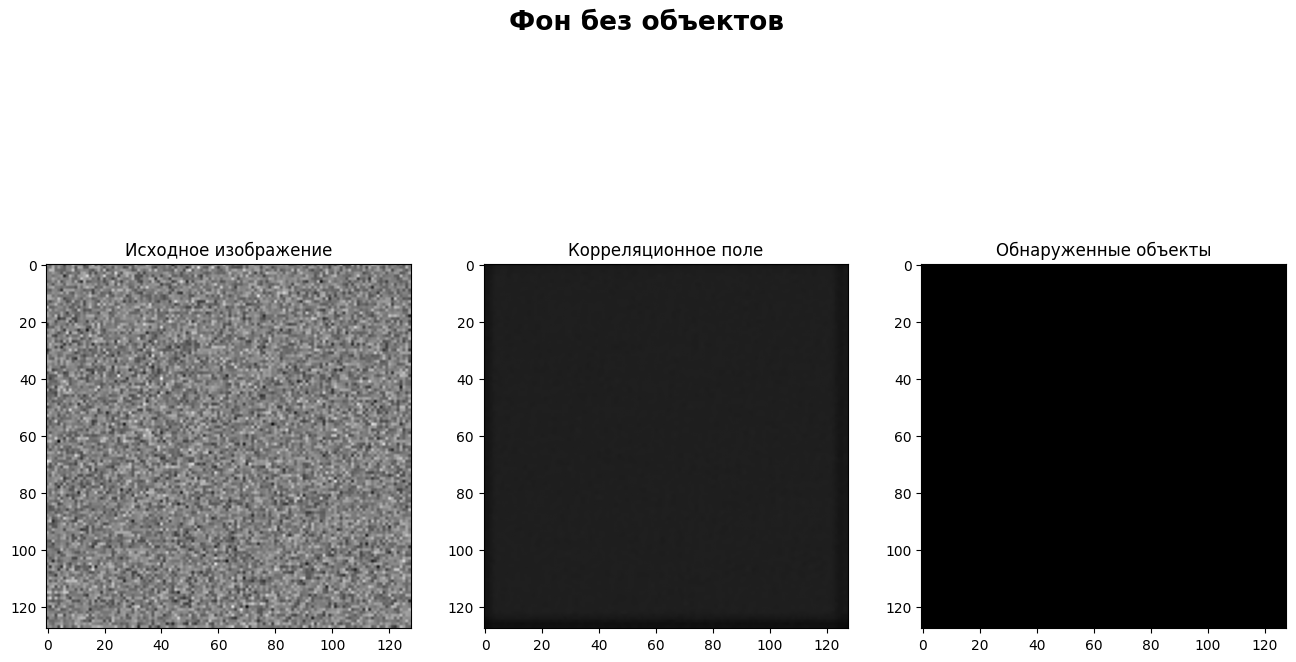

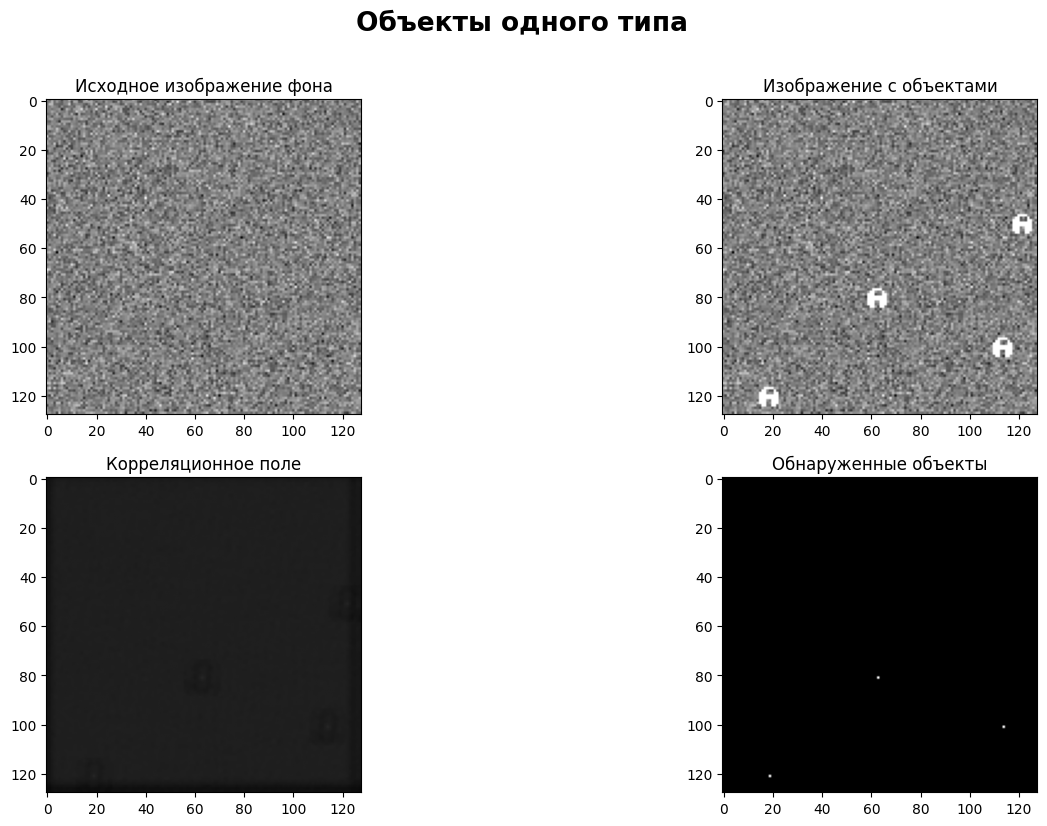

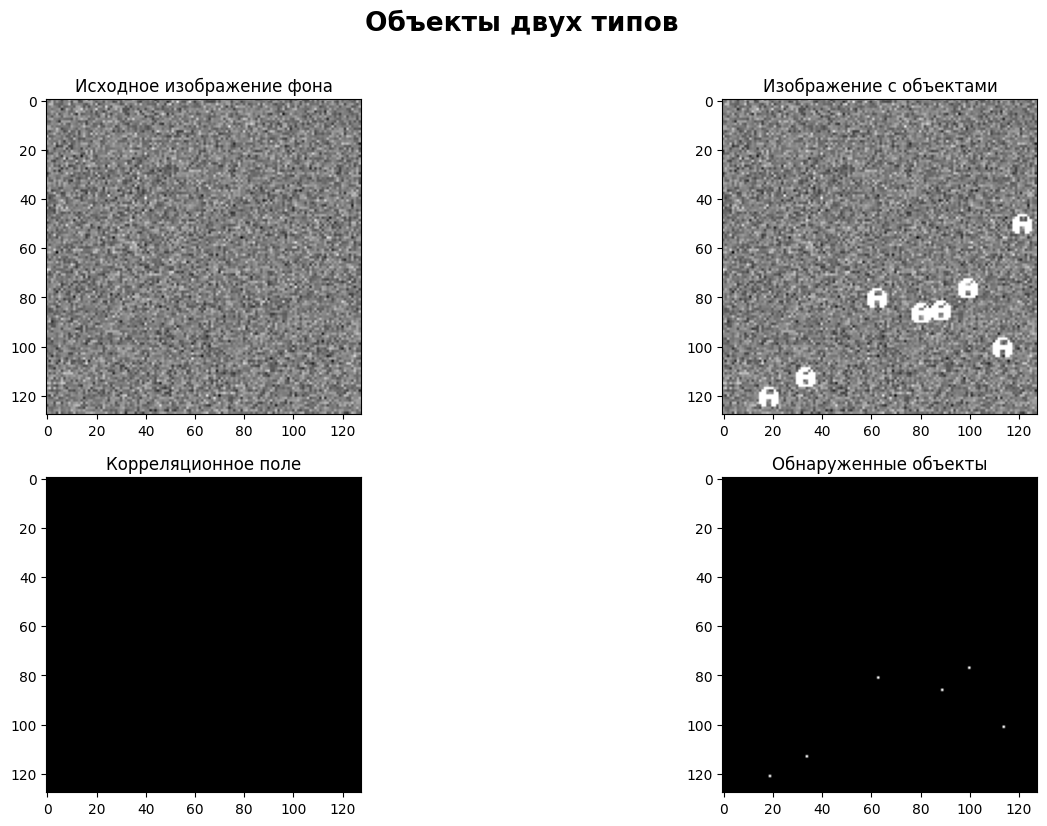

In [55]:
start(3000)

Максимальное значение корреляционного поля: 0.14
Количество обнаруженных объектов на изображении без объектов: 0
Количество обнаруженных объектов на изображении с одним объектом: 3
Количество обнаруженных объектов на изображении с двумя объектами: 3


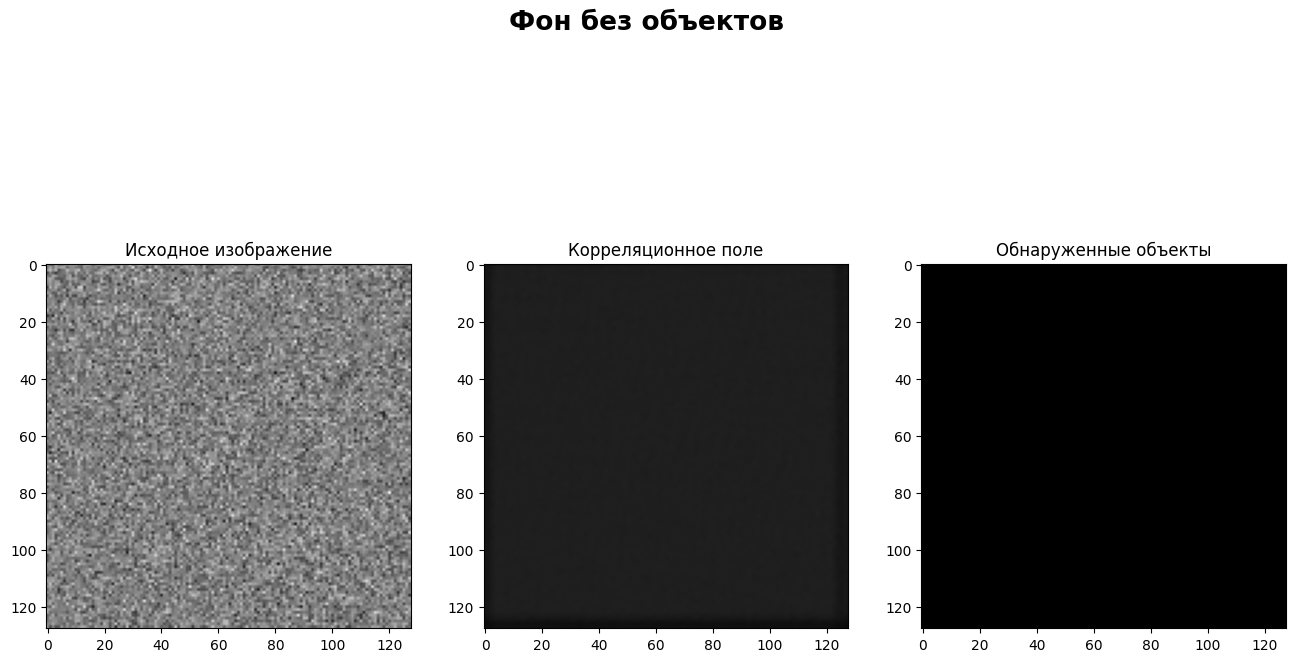

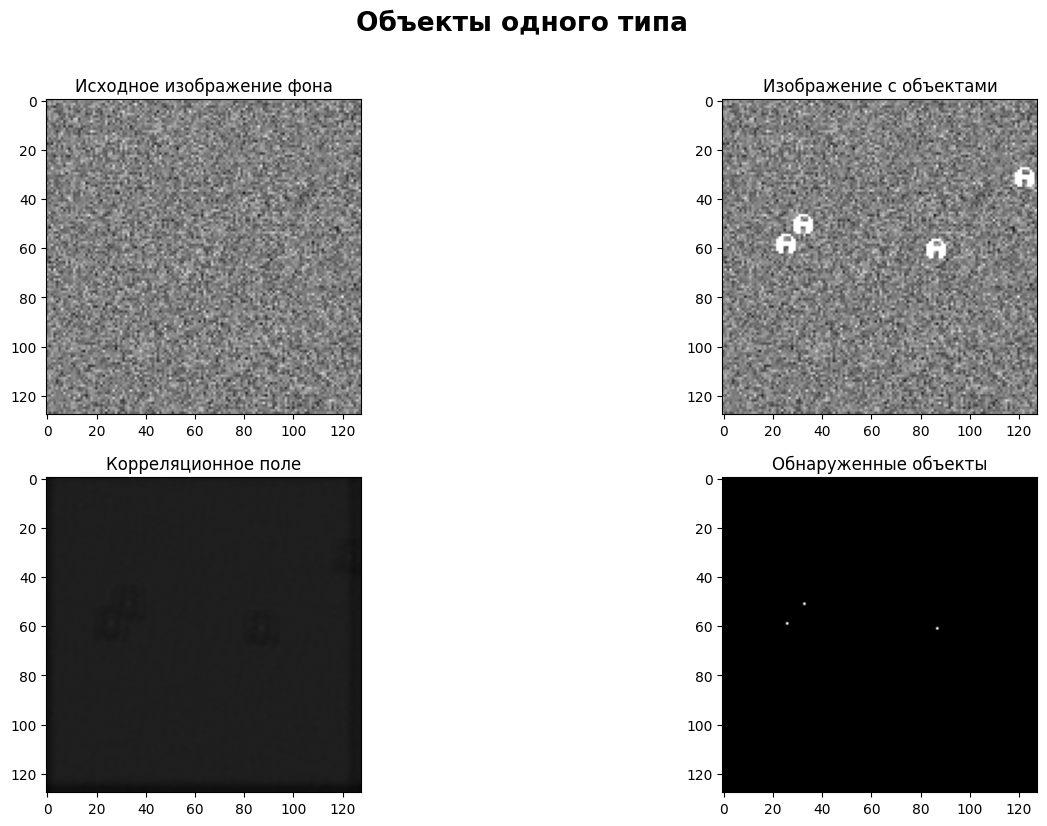

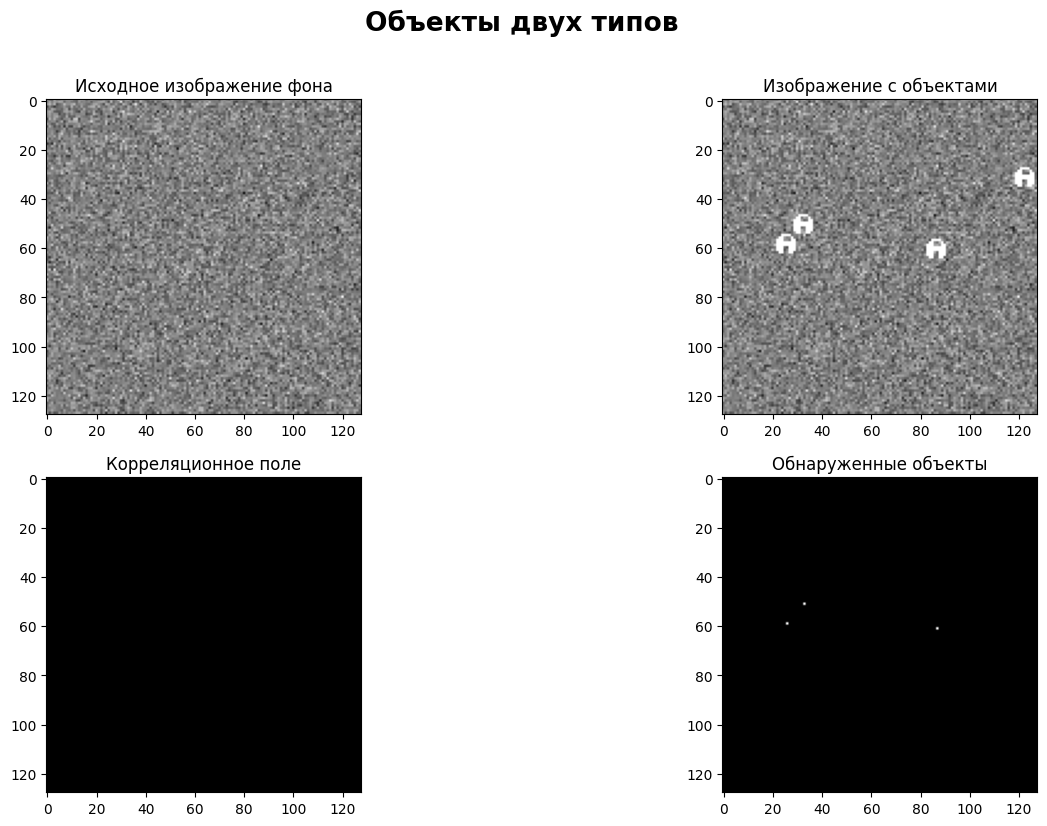

In [56]:
start(5000)